# Programare Python - Curs 5 2023-2024


## Functii (continuare)

### Accesul la variabilele definite in afara functiilor variabile globale

Python permite funcțiilor să acceseze variabile definite în afara lor (din domeniul global sau din domenii exterioare). Aceste variabile pot fi citite direct în interiorul funcției.
Dacă însă se face o atribuire asupra unei astfel de variabile în interiorul funcției, Python o consideră implicit variabilă locală. Pentru a modifica variabila globală este necesară declarația global, iar pentru variabile dintr-un domeniu exterior (dar nu global) se folosește nonlocal.
În cazul obiectelor mutabile, conținutul lor poate fi modificat fără global, deoarece nu se schimbă referința variabilei.

In [ ]:
m = 32


def findme(a):
  print(m)

findme(12)

32


Daca variabila este declarata dupa apelul functiei,
aceasta nu va fi disponibila ca referinta in interiorul acesteia.

In [ ]:
def findme2(a):
  print(mmm)

findme2(12)
mmm = 32

NameError: name 'mmm' is not defined

variabilele globale nu pot fi modificate in interiorul functiei ca si cum ar fi o variabila normala.

In [4]:
mm = 32


def findme(a):
  mm = 100
  print(mm)


findme(12)
print('afara: ', mm)

100
afara:  32


Python determină dacă o variabilă este locală, globală sau nonlocală în momentul definirii funcției (la analiză/compilare), parcurgând codul pentru a identifica atribuiri și declarații, nu în timpul execuției. Urmatorul cod va produce o eroare, pentru ca instructiunea de atribuire `m=21` forteaza tratarea variabilei m in interiorul functiei ca fiind locala si la momentul la care se executa print() ea nu este definita.  

In [ ]:
m = 32


def findme(a):
  print(m)
  m=21

findme(12)

UnboundLocalError: cannot access local variable 'm' where it is not associated with a value

Pentru a modifica variabila globala in itneriorul functiei trebuie sa semnalam acest lucru.  Aceasta se face, putin contraintuitiv, local (ca si in PHP de exemplu)

In [ ]:
m = 32


def changemeingl(a):
  global m
  print(id(m))
  m = 21
  print(id(m))


print(id(m))
changemeingl(12)
print(id(m))
print(m)

11646344
11646344
11645992
11645992
21


### Argumente pozitionale si argumente denumite (keyword)

Multe functii in Python permit trimiterea unor argumente specificand direct valoarea acesteia (sau o variabila care o detine) sau specificand o eticheta a argumentului, semnul egal si valoareea argumentului. De exemplu in urmatorul apel al functii print:

In [ ]:
print(2, 1, 3, 4, sep=' <-> ')

2 <-> 1 <-> 3 <-> 4


primele argumente (2,1,3,4) se numesc argumente pozitionale (datorita faptului ca ordinea lor conteaza si tot ce le defineste in referintele in care vor fi reluate in itneriorul functiei este pozitia acestora) iar argumentul end=' ' este un argument de tip keyword

In [ ]:
help(print)

Help on built-in function print in module builtins:

print(*args, sep=' ', end='\n', file=None, flush=False)
    Prints the values to a stream, or to sys.stdout by default.

    sep
      string inserted between values, default a space.
    end
      string appended after the last value, default a newline.
    file
      a file-like object (stream); defaults to the current sys.stdout.
    flush
      whether to forcibly flush the stream.



Daca privim help-ul functiei print observam ca sunt disponibile mnai multe argumente de tip keyword.

Pentru a defini parametrii de tip keyword intr-o functie trebuie sa fie numiti la momentul definirii acesteia

In [ ]:
def mykwparfunc(one = 1, two = 0):
  print('one: ', one)
  print('two: ', two)
  print(' --- ')

mykwparfunc(one = 10, two = 12) #apel normal
mykwparfunc(two = 12, one = 10) # apel cu argumente inversate
mykwparfunc(50, 112) # apel cu argumente pozitionale
mykwparfunc(112, 50) # apel cu argumente pozitionale inversate
mykwparfunc(70, two = 212) # apel cu argumente mixte, respectand pozitia
mykwparfunc()

one:  10
two:  12
 --- 
one:  10
two:  12
 --- 
one:  50
two:  112
 --- 
one:  112
two:  50
 --- 
one:  70
two:  212
 --- 
one:  1
two:  0
 --- 


daca incercam un apel cu argumente mixte dar nu respectam pozitia parametrului pozitional, vom capata o eroare:

In [ ]:
mykwparfunc(70, one = 212) # apel cu argumente mixte, nerespectand pozitia

TypeError: mykwparfunc() got multiple values for argument 'one'

Putem forta apelul cu argumente de tip keyword?

Python 3.8 a introdus o modificare relevanta in acest moment. Inainte de python 3.8 declaratia unei functii era astfel:

```python
def functie(parametrii pozitionali sau keyword, *, parametrii_care_sunt_exclusiv_keyword):
```
dupa python 3.8 declaratia astata astfel:

```python
def name(parametrii_exclusiv_pozitionali, /, parametrii_pozitionali_sau_kw, *, parametrii_exclusiv_kw):
```  

In [ ]:
def myallparfunc(pone,ptwo, /, one = 1, two = 0, *, three = 0, four=0):
  print('pone: ', pone)
  print('ptwo: ', ptwo)

  print('one: ', one)
  print('two: ', two)
  print('three: ', three)
  print('four: ', four)
  print(' --- ')


myallparfunc(12,13)

pone:  12
ptwo:  13
one:  1
two:  0
three:  0
four:  0
 --- 


In [ ]:
myallparfunc(12,13,14,15)

pone:  12
ptwo:  13
one:  14
two:  15
three:  0
four:  0
 --- 


In [ ]:
myallparfunc(12,13,14,15,16,17)

TypeError: myallparfunc() takes from 2 to 4 positional arguments but 6 were given

Observam ca:

parametrii dinainte de / sunt exclusiv pozitionali, acestia sunt obligatorii

- Parametrii din mijloc (dintre / si *) sunt semi-pozitionali care au valori predefinite, functia poate fi apelata cu acesti parametrii ca parametrii pozitionali sau ca parametrii de tip keyword
- Parametrii finali (dupa *) sunt parametrii de tip keyword care nu pot fi apelati decat ca parametrii de tip keywords.
- Ultimii doi parametrii (three, four) trebuie obligatoriu sa fie chemati cu numele lor.

La definirea functiei trebuie tinut cont de tipurile de date necesare si de modul de apelare dorit. Parametrii de tip exclusiv keyword pot fi utilizati pentru a specifica o lista de valori predefinite a caror modificare poate fi dorita sporadic. Aceasta ii face sa poata fi evitati de la majoritatea apelarilor, fara consecinte asupra executiei functiei datorita existentei valorilor predefinite.

### Functii cu numar variabil de argumente

Sunt situatii in care nu stim exact cate argumente va primi functia. Putem defini functii care vor primi un numar variabil de argumente

#### Functii cu numar variabil de parametrii pozitionali

In [ ]:
def suma(*numere):
    suma = 0
    for num in numere:
        suma = suma + num
    return suma

print(suma(12,34,56))
print(suma(12))
print(suma(12,34,56,54,67,897,23,54,23))

102
12
1220


Ar fi interesant de vazut exact ce tip are variabila "numbers". Acest tip este tuplul. Putem verifica, rescriind functia astfel incat sa imprime tipul variabilei "numere"

In [ ]:
def suma_t(*numere):
    print (type(numere))
    suma = 0
    for num in numere:
        suma = suma + num
    return suma

print(suma_t(12,34,56))
print(suma_t(12))
print(suma_t(12,34,56,54,67,897,23,54,23))

<class 'tuple'>
102
<class 'tuple'>
12
<class 'tuple'>
1220


Argumentele trimise catre functie sunt puse intr-un tuplu iar acesta este "despachetat" in interiorul functiei. Despachetarea permite variabile cu stea, variabile care vor acumula tot ce ramane neatribuit in cele dinaintea lor

#### Functii cu numar variabil de parametrii de tip keyword

O functie poate astepta un numar variabil de parametrii de tip keyword.

In [ ]:
def calculate_total_cost(price, **kwargs):
    tax_rate = kwargs.get('tax_rate', 0.05)
    discount = kwargs.get('discount', 0)
    shipping_cost = kwargs.get('shipping_cost', 5.0)

    total_cost = price + (price * tax_rate) - discount + shipping_cost
    return total_cost

# Example usage
price = 100.0
total_cost = calculate_total_cost(price, tax_rate=0.08, discount=10.0, shipping_cost=8.0)
print(f"Total cost: {total_cost}")

Total cost: 106.0


Evident, ca si in cazul parametrilor pozitionali variabili, o lista variabila de parametrii, se poate inlocui cu un singur parametru de tip dictionar

### Functii ca "first class citizens"

"first class citizen" inseamna ca functiile au aceleasi "drepturi" ca variabilele. Adica functiile pot fi atribuite variabilelor si pot fi returnate din alte functii.

In exemplul urmator, o functie este folosita ca parametru al altei functii

In [ ]:
def add_numbers(a, b):
    return a + b

def subtract_numbers(a, b):
    return a - b

def calculate(operation, a, b):
    return operation(a, b)

# Example usage
result1 = calculate(add_numbers, 10, 5)
result2 = calculate(subtract_numbers, 10, 5)
print(f"Result1: {result1}")
print(f"Result2: {result2}")

Result1: 15
Result2: 5


Functiile pot fi atribuite unor variabile si apelate ulterior cu ajutorul acestora

> Add blockquote



In [ ]:
def add_numbers(a, b):
    return a + b

my_function = add_numbers

result = my_function(5, 10)
print(result)

15


Functii pot returna alte functii:

In [ ]:
def create_multiplier(n):
    def multiply(x):
        return x * n
    return multiply

# Example usage
double = create_multiplier(2)
triple = create_multiplier(3)

print(double(5))
print(triple(5))

10
15


### LEGB

LEGB este un acronim care arata ordinea in care Python cauta un nume

- Local - functia curenta
- Enclosing - functia imediat superioara, daca exista
- Global - la nivelul modulului
- Builtin - namespace global

LEGB se refera la urdinea cautarii NUMELOR - atribuirile au un set suplimentar de reguli

In [14]:
x = "global"

def outer():
    x = "enclosing"

    def inner():
        x = "local"
        print(x)

    inner()

outer()

global


### Functii lambda

Functiile lambda sunt mici functii anonime de care este nevoie in anumite operatii (ex: sortare).

Functiile de tip lambda nu pot contine instructiuni de atribuire, blocuri if, for, while, return



In [ ]:
# declaratia unei functii lambda
lmsalut = lambda : print('Hello World')

# apelul unei functii lambda
lmsalut()

Hello World


Functiile lambda sunt limitate la o singaura expresie, ele sunt menite unor utilizari foarte simple, in special in expresii asociate altor functii.

In [ ]:
numbers = [1, 2, 3, 4]
squared = list(map(lambda x: x**2, numbers))

print(squared)

[1, 4, 9, 16]


Evident, putem obtine acelasi efect folosind o functie denumita

In [ ]:
# Defining a named function to square all items in a list
def square(x):
    return x**2

squared2 = list(map(square, numbers))

print(squared)

[1, 4, 9, 16]


#### Exemple de utilizare a functiilor lambda

In [ ]:
#Filtrarea numerelor pare dintr-o lista

numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
filtered_list = list(filter(lambda x: x % 2 == 0, numbers))
print(filtered_list)

[2, 4, 6, 8, 10]


In [6]:
conducatori = [
 	{ "nume": "Lulu", "conduce": ["bicicleta", "masina"] },
 	{ "nume": "Judith", "conduce": ["trotineta", "vapor"] },
 	{ "nume": "Alladin", "conduce": ["trotineta", "role", "bicicleta"] },
 	{ "nume": "Heidi", "conduce": ["avion", "role", "bicicleta"] }]

In [ ]:
biciclisti = list(filter(lambda x: "bicicleta" in x['conduce'], conducatori))

print(biciclisti)

[{'nume': 'Lulu', 'conduce': ['bicicleta', 'masina']}, {'nume': 'Alladin', 'conduce': ['trotineta', 'role', 'bicicleta']}, {'nume': 'Heidi', 'conduce': ['avion', 'role', 'bicicleta']}]


De cele mai multe ori, in special in cazul listelor, dictionarelor... etc. lambda sunt inlocuite cu expresii de tip comprehension

In [7]:
biciclisti = list(filter(lambda x: "bicicleta" in x['conduce'], conducatori))

print(biciclisti)

[{'nume': 'Lulu', 'conduce': ['bicicleta', 'masina']}, {'nume': 'Alladin', 'conduce': ['trotineta', 'role', 'bicicleta']}, {'nume': 'Heidi', 'conduce': ['avion', 'role', 'bicicleta']}]


care sunt mai flexibile

In [8]:
biciclisti = [x["nume"] for x in conducatori if "bicicleta" in x["conduce"]]

print(biciclisti)

['Lulu', 'Alladin', 'Heidi']


Pentru a obtine doar numele folosind functii lambda trebuie sa crestem complexitatea constructiei:

In [9]:
biciclisti = list(
    map(lambda x: x["nume"],
        filter(lambda x: "bicicleta" in x["conduce"], conducatori))
)

print(biciclisti)

['Lulu', 'Alladin', 'Heidi']


utilizarea functiei map pentru a aplica o operatie asupra tuturor elementelor unei liste

In [ ]:
numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
doubled_list = list(map(lambda x: x * 2, numbers))
print(doubled_list) # [2, 4, 6, 8, 10]

[2, 4, 6, 8, 10, 12, 14, 16, 18, 20]


utilizarea functiei "reduce" pentru a obtine un rezultat sumar pe baza elementelor unei liste

functia reduce asteapta o functie lambda cu doua argumente iar aplicarea acesteia este urmatoarea: primele doua elemente ale listei sunt supuse operatiei din functie, apoi rezultatul operatiei si cel de-al treilea element sunt supuse operatiei, apoi rezultatul si cel de-al patrulea... etc.

In [ ]:
from functools import reduce

numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
suma = reduce(lambda x, y: x + y, numbers)
print(suma)

55


### Recursivitate

Python permite recursivitate. Celebrul factorial:

In [ ]:
def factorial(n):
    if n == 0:
        return 1
    else:
        return n * factorial(n-1)

# Example usage
print(factorial(5)) # Output: 120

120


cel mai mare divizor comun

In [ ]:
def cmmdc(a, b):
    if b == 0:
        return a
    else:
        return cmmdc(b, a % b)


print(cmmdc(24, 36))

12


### Closures

Inchiderile (closures) sunt un tip de functii care sunt returnate de alte functii si care contin si mediul in care au fost apelate (variabilele definite la momentul definirii functiei).

O inchidere implica in general existenta unei functii exterioare si a unei functii interioare care va fi returnata.

In [ ]:
def outer_func(x):
    def inner_func(y):
        return x + y
    return inner_func

add_five = outer_func(5)

result = add_five(10)
print(result)

15


Variabilele definite in afara functiei interioare sunt retinute si dupa finalizarea executiei functiei outer_func.

In [1]:
def outer_func(x):
    alfa = 21
    def inner_func(y):
        return x + y + alfa
    return inner_func

add_five = outer_func(5)

result = add_five(10)
print(result)

36


### Decoratori

In [ ]:
def my_decorator(func):
    def wrapper():
        print("Before function call")
        func()
        print("After function call")
    return wrapper

@my_decorator
def my_function():
    print("Function being called")

my_function()

Before function call
Function being called
After function call


In exemplul urmator putem folosi decoratorul petnru a masura durata executiti unei functii

In [ ]:
import time
import math

def calculate_time(func):

    def inner1(*args, **kwargs):
        begin = time.time()
        func(*args, **kwargs)
        end = time.time()
        print("Total time taken in : ", func.__name__, end - begin)

    return inner1

@calculate_time
def factorial(num):

    time.sleep(2)
    print(math.factorial(num))

factorial(10)

@calculate_time
def collatz_sequence(n):
    sequence = [n]
    while n != 1:
        if n % 2 == 0:
            n = n // 2
        else:
            n = 3 * n + 1
        sequence.append(n)
    return sequence

collatz_sequence(27)

3628800
Total time taken in :  factorial 2.002150297164917
Total time taken in :  collatz_sequence 4.38690185546875e-05


Un alt exemplu foarte util este un sistem de cache al rezultatelor unor operatii care dureaza foarte mult.

In [5]:
import time

def cache_decorator(f):
    cache = {}
    def wrapper(x):
        if x in cache:
            print(f"din cache: square({x}) = {cache[x]}")
            return cache[x]
        print(f"calculez: square({x})")
        result = f(x)
        cache[x] = result
        return result
    return wrapper


@cache_decorator
def square(x):
    time.sleep(2)
    return x * x


print(square(8))
print(square(5))
print(square(8))
print(square(3))
print(square(5))

calculez: square(8)
64
calculez: square(5)
25
din cache: square(8) = 64
64
calculez: square(3)
9
din cache: square(5) = 25
25


Exista chiar un o functie pentru aceasta

In [6]:
from functools import lru_cache

@lru_cache
def square(x):
    time.sleep(2)
    return x * x

print(square(8))
print(square(5))
print(square(8))
print(square(3))
print(square(5))

64
25
64
9
25


Decoratoarele pot fi inlantuite

In [ ]:
def printegal(func):
    def inner(*args, **kwargs):
        print("=" * 15)
        func(*args, **kwargs)
        print("=" * 15)
    return inner


def printminus(func):
    def inner(*args, **kwargs):
        print("-" * 15)
        func(*args, **kwargs)
        print("-" * 15)
    return inner


@printegal
@printminus
def salutare(msg):
    print(msg)

salutare("Hello")

---------------
Hello
---------------


### Generatori

Un generator este un tip special de functie care este apelata o singura data si poate returna valori de mai multe ori.

Aceasta se face prin returnarea unui obiect de tip generator care ruleaza functia din nou de cate ori este apelat.

Denumirea de generator vine de la utilizarea acestor functii pentru generarea unor secvente care presupun fie calcule complexe (si generarea intregii liste ar opri programul) fie pot fi extrem de variabile si nu are sens sa se genereze o lista foarte mare degeaba.

Exemplu de generator:

In [ ]:
def count_up_to(n):
    i = 1
    while i <= n:
        yield i
        i += 1

Se observa ca nu exista alte cuvinte cheie implicate in definirea generatorului, acesta este "ghicit" de compilator datorita prezentei cuvantului "yield" in stanga expresiei.

Apelul acestuia se face intr-o prima faze similar cu apelul oricarei functii, apoi se foloseste functia next pentru a obtine restul elementelor

In [ ]:
mg = count_up_to(10)

In [ ]:
print (next(mg))
print (next(mg))
print (next(mg))

1
2
3


Daca executam de mai multe ori celula cu print(next) vom obtine valori succesive, generatorul ramane in rulare. Pentru a reinitializa generatorul trebuie sa rulam din nou si celula cu

```
    mg = count_up_to(10)
```  

#### Obiectul generator si metodele lui

In [ ]:
print(mg.__class__)
print(dir(mg))

<class 'generator'>
['__class__', '__del__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__lt__', '__name__', '__ne__', '__new__', '__next__', '__qualname__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', 'close', 'gi_code', 'gi_frame', 'gi_running', 'gi_yieldfrom', 'send', 'throw']


Se observa ca interpretorul a captat automat intentia de a construi un generator si, desi cuvantul return nu exista in corpul functiei, a returnat ceva. Acel ceva este un obiect instantiat din clasa generator.

Metodele apelabile sunt urmatoarele

- **close**  Inchide generatorul inainte de vreme. Nu e necesara (cum este la fisiere) si functioneaza prin generarea unei exceptii de tip GeneratorExit. Utila pentru generatori infiniti (fara conditie interioara de oprire)
- **gi_code** Obiectul de cod care contine functia generator (bytecode-ul). Spre deosebire de metoda
- **code** disponibila pentru orice functie,
- **gi_code** permite vizualizarea starii curente a generatorului
- **gi_frame** Referinta catre frame-ul curent din memoria masinii virtuale unde se gaseste generatorul. Similara cu **code**.co_frame dar si aici cu informatii suplimentare necesare pentru rularea generatorului
- **gi_running** Variabila booleana care arata daca generatorul ruleaza in  momentul apelarii
- **gi_yieldfrom** Afiseaza obiectul iterator din care se produce yield-ul
- **send** Permite trimiterea unor valori catre generator. Pentru aceasta, generatorul trebuie sa aiba o instructiune de genul x = yield in interior, transformandu-se in corutina
- **throw** metoda determina generatorul sa emita o erare

##### generator.gi_code()

In [ ]:
def count_up_to_e2(n):
    try:
      i = 1
      while i <= n:
          yield i
          i += 1
    except GeneratorExit:
        print('Count stopped.')

g2 = count_up_to_e2(5)
print(next(g2))
print(g2.gi_code.co_code)
print(g2.gi_code.co_consts)
print(g2.gi_code.co_varnames)
print(next(g2))


1
b'\x81\x00z\x17d\x01}\x01|\x01|\x00k\x01r\x16|\x01V\x00\x01\x00|\x01d\x017\x00}\x01|\x01|\x00k\x01s\x08W\x00d\x00S\x00W\x00d\x00S\x00\x04\x00t\x00y&\x01\x00\x01\x00\x01\x00t\x01d\x02\x83\x01\x01\x00Y\x00d\x00S\x00w\x00'
(None, 1, 'Count stopped.')
('n', 'i')
2


### Corutine

Corutinele sunt generalizari ale subrutinelor si generatorilor.

O subrutina are un punct de intrare si un punct de iesire, este ca un fir.

Un generator are un singur punct de intrare si mai multe puncte de iesire

O corutina are mai multe puncte de intrare si, posibil, mai multe puncte de iesire

In [ ]:
def coroutine_1():
    print("Coroutina porneste")
    while True:
        value = yield
        print("Coroutina primeste:", value)

In [ ]:
coro = coroutine_1()
next(coro)
coro.send(10)
coro.send(20)
coro.send(30)

Coroutina porneste
Coroutina primeste: 10
Coroutina primeste: 20
Coroutina primeste: 30


Corutina poate contine mai mutle intructiuni yield.

In [ ]:
def coroutine_d():
    print("Coroutina porneste")
    while True:
        value = yield
        print("Coroutina primeste 1:", value)
        value2 = yield
        print("Coroutina primeste 2:", value2)

coro = coroutine_d()
next(coro)
coro.send(10)
coro.send(20)
coro.send(30)

Coroutina porneste
Coroutina primeste 1: 10
Coroutina primeste 2: 20
Coroutina primeste 1: 30


Corutinele de obicei nu returneaza pentru ca aceasta le inchide. Corutinele sunt utilizate de regula pentru a lansa in executie (de obicei asincrona) o serie de alte functii. Dar, corutinele pot executa operatia de yield ca si generatorii cu putina atentie, dupa cum se vede in exemplul urmator:

In [ ]:
def more_coroutine():
    val = 0
    while True:
        val = yield
        if val == 'exit':
            yield None
            return
        yield val

coro = more_coroutine()
coro.send(None)

for i in range(5):
    result = coro.send(i)
    coro.send(None)
    print(result)

coro.send('exit')

0
1
2
3
4


De ce este nevoie de  coro.send(None) imediat dupa result = coro.send(i)? Penmtru ca instructiunea yield val (ultime linie din functia more_coroutine) nu doar returneaza val ci si suspenda executia la o instructiune yield care nu este pregatita sa primeasca date ci doar sa le trimita.

coro.send(None) muta executia la urmatorul yield astfel incat urmatorul coro.send(i) sa inceapa executia de unde ne dorim

Putem (daca ceea ce facem ne permite aceasta) sa folosim o singura instructiune yield care sa primeasca si sa trimita in acelasi timp. Dupa cum se vede in exemplul urmator, aceasta nu mai are nevoie de send(None) pentru ca executia functiei este suspendata exact la instructiunea care (in timpo ce trimite) asteapta date de la functia apelanta. Problema cu aceasta abordare este ca nu putem face mare lucru cu valorile intr-o simpla linie de cod.

In [ ]:
def more_coroutine():
    val = 0
    while True:
        val = yield val + 3
        if val == 'exit':
            yield None
            return


coro = more_coroutine()
coro.send(None)

for i in range(5):
    result = coro.send(i)
    print(result)

coro.send('exit')


3
4
5
6
7


Pentru a vedea un caz ceva mai "real" putem sa inspectam (daca suntem pe google collaboratory) unul dintre seturile de date pe care le primim automat la initializarea oricarui notebook. Acestea se gasesc in directorul sample_data

In [ ]:
!ls -all sample_data

total 55512
drwxr-xr-x 1 root root     4096 Apr 11 13:21 .
drwxr-xr-x 1 root root     4096 Apr 11 13:21 ..
-rwxr-xr-x 1 root root     1697 Jan  1  2000 anscombe.json
-rw-r--r-- 1 root root   301141 Apr 11 13:21 california_housing_test.csv
-rw-r--r-- 1 root root  1706430 Apr 11 13:21 california_housing_train.csv
-rw-r--r-- 1 root root 18289443 Apr 11 13:21 mnist_test.csv
-rw-r--r-- 1 root root 36523880 Apr 11 13:21 mnist_train_small.csv
-rwxr-xr-x 1 root root      930 Jan  1  2000 README.md


toate datele sunt in format csv, putem folosi unul dintre ele pentru a testa corutinele. Intai sa aflam cum arata, tot cu comenzi de sistem. E mult mai simplu decat sa il incarcam in notebook si sa il inspectam.

In [ ]:
!head -n 20 sample_data/mnist_test.csv

7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,84,185,159,151,60,36,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,222,254,254,254,254,241,198,198,198,198,198,198,198,198,170,52,0,0,0,0,0,0,0,0,0,0,0,0,67,114,72,114,163,227,254,225,254,254,254,250,229,254,254,140,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,17,66,14,67,67,67,59,21,236,254,106,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,83,253,209,18,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,22,233,255,83,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,129,254,238,44,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,59,249,254,62,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,133,254,187,5,0,0

Fisierul are o gramada de cifre pe o linie si nimic altceva. Incercam sa vedem (tot cu comenzi de sistem) cat de multe sunt

In [ ]:
!wc -l sample_data/mnist_test.csv

10000 sample_data/mnist_test.csv


comanda ne arata ca avem 10000 de linii in fisier, mult prea multe fata de ce avem noi nevoie

In [25]:
import csv
import time

def process_row():
    while True:
    # perform some processing on the row
      row = yield
      time.sleep(1)
      if row is not None:
        cu = 0
        for hh in row:
          cu = cu + int(hh)
        yield cu

def process_csv(input_filename):
    with open(input_filename, 'r') as input_file:

        reader = csv.reader(input_file)
        coro = process_row()
        coro.send(None)        ## avanseaza codul la primul yield (priming the coroutine)
        cnt = 1
        for row in reader:
           if cnt < 10:
              result = coro.send(row)
              coro.send(None)
              print(str(cnt) + ': ' + str(result))
              cnt = cnt+1



In [26]:
input_filename = 'sample_data/mnist_test.csv'

process_csv(input_filename)

1: 18461
2: 28852
3: 9872
4: 37014
5: 19241
6: 13856
7: 21188
8: 21071
9: 30739


In [27]:
import numpy as np
import csv
import matplotlib.pyplot as plt

def plot_mnist_from_csv(file_path, line_number):
    try:
        with open(file_path, 'r') as file:
            reader = csv.reader(file)
            for i, row in enumerate(reader, start=1):
                if i == line_number:
                    # Convertim elementele randului la numere intregi
                    data = list(map(int, row))
                    label = data[0]  # primul element este labelul (cifra pe care o reprezinta)
                    image_data = data[1:]  # Urmatoarele elemente sunt pixeli ai aimginii

                    if len(image_data) != 784:
                        print("Eroare: Imaginea nu are 784 pixeli")
                        return
                    image_size=(4, 4)
                    # redimensionare si afisare
                    image_matrix = np.array(image_data).reshape(28, 28)
                    plt.figure(figsize=image_size)
                    plt.imshow(image_matrix, cmap='gray')
                    plt.title(f'MNIST Digit: {label}')
                    plt.colorbar()
                    plt.show()
                    return
        print(f"Line {line_number} not found in file.")
    except Exception as e:
        print(f"An error occurred: {e}")




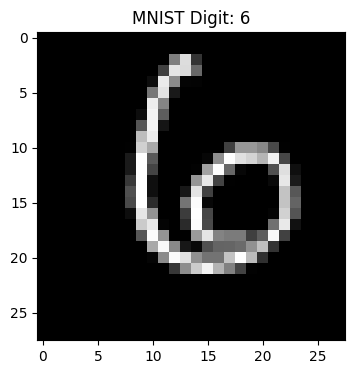

In [28]:

file_path ='sample_data/mnist_test.csv'
line_number = 101
plot_mnist_from_csv(file_path, line_number)

## Expresii regulate

O expresie regulata este o succesiune de caractere (normale sau speciale) care se constituie intr-o structura de cautare (sablon).

O structura de cautare este o succesiune de caractere care poate sa "se potriveasca" cu mai multe siruri de caractere diferite dar care sunt asemanatoare structural


Expresiile regulate sunt implementate in Python intr-un modul extern numit re

Principalele metode sunt:

------------------------------
| metoda | Definitie |
| -------|-----------|
| findall | gaseste toate fragmentele de text care se potrivesc cu patternul. Returneaz o lista |
| search | Cauta si returneaza sub forma unui obiect de tip Match prima instanta care se potriveste cu patternul |
| split  | Separa un sir de caractere dupa o expresie regulata |
| sub    | Inlocuieste anumite structuri identificate cu ajutorul unei expresii regulate cu alte structuri |


In [17]:
import re

text = "Numarul meu de telefon este 1234567890 si numarul cardului meu de credit este 9876543210987654."

pattern = '\d\d\d\d\d\d\d\d\d\d'

results = re.findall(pattern,  text)

for match in results:
  print (str(type(match)) + ': ' + match)

<class 'str'>: 1234567890
<class 'str'>: 9876543210


<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_20617/4213832180.py:5: SyntaxWarning: invalid escape sequence '\d'
  pattern = '\d\d\d\d\d\d\d\d\d\d'


In [18]:
pattern = r'\d\d\d\d\d\d\d\d\d\d'

results = re.findall(pattern,  text)

for match in results:
  print (str(type(match)) + ': ' + match)

<class 'str'>: 1234567890
<class 'str'>: 9876543210


In [ ]:
textnm = 'Rick and Nick have decided to visit Dick because he is sick'

pattern = '.ick'

results = re.findall(pattern,  textnm)

for match in results:
  print (str(type(match)) + ': ' + match)

<class 'str'>: Rick
<class 'str'>: Nick
<class 'str'>: Dick
<class 'str'>: sick


Putem separa doar numele proprii? fara sick

In [ ]:
textnm = 'Rick and Nick have decided to visit Dick because he is sick'

pattern = '[A-Z]ick'

results = re.findall(pattern,  textnm)

for match in results:
  print (str(type(match)) + ': ' + match)

<class 'str'>: Rick
<class 'str'>: Nick
<class 'str'>: Dick


Patternul poate deveni extrem de complicat

https://www.dataquest.io/wp-content/uploads/2019/03/python-regular-expressions-cheat-sheet.pdf


Putem gasi o expresie regulata care sa "se potriveasca" cu orice adresa de e-mail?

(username)@(domainname).(top-leveldomain)

(string1)@(string2).(2+characters)

In [ ]:
emailad = 'ana.are.mere@domeniu.ro si vasile nu are deloc'

pattern = 'ana'

result = re.search(pattern,  emailad)

if result is not None:
  print(type(result))
  print(dir(result))
  print(result.group())
  print('start:' + str(result.start()))
  print('end:' + str(result.end()))

<class 're.Match'>
['__class__', '__class_getitem__', '__copy__', '__deepcopy__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', 'end', 'endpos', 'expand', 'group', 'groupdict', 'groups', 'lastgroup', 'lastindex', 'pos', 're', 'regs', 'span', 'start', 'string']
ana
start:0
end:3


caracterul punct (.) tine locul oricarui caracter (mai putin newline) iar * inseamna "repetare de oricate ori".

Astfel, patternul ana.*@ va cuprinde ana si tot ceea ce urmeaza pana la intalnirea caracterului @.

In [ ]:
emailad = 'ana.are.mere@domeniu.ro si vasile nu are deloc'

pattern = 'ana.*@'

result = re.search(pattern,  emailad)

if result is not None:
  print(result.group())
  print('start:' + str(result.start()))
  print('end:' + str(result.end()))

ana.are.mere@
start:0
end:13


Ce se intampla daca sunt mai multe @ in sir?

In [ ]:
emailad = 'ana.are.mere@domeniu.ro si @vasile nu are @deloc'

pattern = 'ana.*@'

result = re.search(pattern,  emailad)

if result is not None:
  print(result.group())
  print('start:' + str(result.start()))
  print('end:' + str(result.end()))

ana.are.mere@domeniu.ro si @vasile nu are @
start:0
end:43


Se observa ca end este la 43, spre deosebire de 13. Aceasta inseamna ca morotul de expresii regulate s-a dus "cat de departe a putut". Acest comportament se numeste "greedy (lacom)". Toate caracterele generelizatoare (de tip *, +) au un comportament greedy in mod predefinit.

Daca punem un semn de intrebare imediat dupa cuantificatorul * atunci comportamentul acestuia se schimba din greedy (lacom) in lazy (lenes) si identificarea va merge pana la prima aparitie a caracterului @

In [ ]:
emailad = 'ana.are.mere@domeniu.ro si @vasile nu are @deloc'

pattern = 'ana.*?@'

result = re.search(pattern,  emailad)

if result is not None:
  print(result.group())
  print('start:' + str(result.start()))
  print('end:' + str(result.end()))

ana.are.mere@
start:0
end:13


cum obtinem un match pe intreaga adresa de e-mail?

In [ ]:
emailad = 'ana.are.mere@domeniu.ro si @vasile nu are @deloc'

pattern = '.*?@.*?\s'

result = re.search(pattern,  emailad)

if result is not None:
  print(result.group())

ana.are.mere@domeniu.ro 


ce probleme are aceasta expresie regulata?

1. Daca adresa de e-mail nu incepe la inceputul sirului?

In [ ]:
emailad = 'Adresa mea de email este ana.are.mere@domeniu.ro si @vasile nu are @deloc'

pattern = '.*?@.*?\s'

result = re.search(pattern,  emailad)

if result is not None:
  print(result.group())

Adresa mea de email este ana.are.mere@domeniu.ro 


Nu putem folosi spatiul pentru ca nu este unul singur. Pentru aceasta situatie au fost inventate seturile de caractere. De exemplu setul [a-zA-Z] va recunoaste orice caracter alfanumeric (unul singur daca nu exista cuantificatori). Daca includem si caractelerel permise in prima parte a adresei de e-mail (cifre, caractere speciale) putem sa ne asiguram ca prim parte (partea locala) este identificata corect

In [ ]:
emailad = 'Adresa mea de email este ana.are.mere@domeniu.ro si @vasile nu are @deloc'

pattern = '[a-zA-Z0-9\.]*?@.*?\s'

result = re.search(pattern,  emailad)

if result is not None:
  print(result.group())

ana.are.mere@domeniu.ro 


Partea din dreapta @ este compusa din grupuri de litere separate cu puncte.

Daca textul are mai multe adrese de e-mail si ne dorim identificarea tuturor, folosim findall

In [ ]:
emailad = 'Adresele de email inregistrate sunt urmatoarle: 1234567890@numarulcelmaimare.xxx, gentle-Man@iron-self.tv și almond@caramela.tv. \
De asemenea, sunt inregistrate si anton@big.domain.museum și carcalete@insecticid.co.jp și in final seful-cel-mai-mare@supercompanie.com'

pattern = '[a-zA-Z0-9._%-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,6}'

results = re.findall(pattern,  emailad)

for match in results:
  print (str(type(match)) + ': ' + match)

<class 'str'>: 1234567890@numarulcelmaimare.xxx
<class 'str'>: gentle-Man@iron-self.tv
<class 'str'>: almond@caramela.tv
<class 'str'>: anton@big.domain.museum
<class 'str'>: carcalete@insecticid.co.jp
<class 'str'>: seful-cel-mai-mare@supercompanie.com


fie dat textul urmator

"Asadar, vine un podar, destul de murdar, care spune ca a fost grajdar, exprimandu-se lapidar, clar lipsit complet de abecedar, deloc gospodar, certat cu orice calendar, a carui viata e in zadar si spune ca e miliardar, ca a fost caramidar si nu grajdar si ca se considera solidar cu orice om prins de radar."

Separati toate cuvintele care se termina in "dar"

In [ ]:
dartestxt = "Asadar, vine un podar, destul de murdar, care spune ca a fost grajdar, exprimandu-se lapidar, clar lipsit complet de abecedar, \
deloc gospodar, certat cu orice calendar, a carui viata e in zadar si spune ca e miliardar, ca a fost caramidar si nu grajdar si ca se \
considera solidar cu orice om prins de radar."

pdar = '[a-zA-Z]*?dar'

darresults = re.findall(pdar, dartestxt)

for match in darresults:
  print (str(type(match)) + ': ' + match)

<class 'str'>: Asadar
<class 'str'>: podar
<class 'str'>: murdar
<class 'str'>: grajdar
<class 'str'>: lapidar
<class 'str'>: abecedar
<class 'str'>: gospodar
<class 'str'>: calendar
<class 'str'>: zadar
<class 'str'>: miliardar
<class 'str'>: caramidar
<class 'str'>: grajdar
<class 'str'>: solidar
<class 'str'>: radar


### Split cu ajutorul expresiilor regulate

In [ ]:
split_term = ' '

phrase = "When Chuck Norris enters a room, he doesn't turn the lights on, he turns the dark off"

# Split the phrase
result = re.split(split_term,phrase)

print (type(result))
print (result)

<class 'list'>
['When', 'Chuck', 'Norris', 'enters', 'a', 'room,', 'he', "doesn't", 'turn', 'the', 'lights', 'on,', 'he', 'turns', 'the', 'dark', 'off']


Se observă că utilizarea spațiului în split determină taierea unora dintre cuvinte împreună cu virgula. Putem adăuga virgula la caracterele după care se face splitul, sau, mai bine, combinatia de spatiu si virgula:

In [ ]:
split_term = ' | ,'

phrase = "When Chuck Norris enters a room, he doesn't turn the lights on, he turns the dark off"

# Split the phrase
result = re.split(split_term,phrase)

print (result)

['When', 'Chuck', 'Norris', 'enters', 'a', 'room,', 'he', "doesn't", 'turn', 'the', 'lights', 'on,', 'he', 'turns', 'the', 'dark', 'off']


Ce se întâmplă dacă există mai multe spații în șir? Se poate adauga plus după spatiu: + inseamnă caracterul anterior prezent o data sau de mai multe ori

In [ ]:
split_term = ' +|, +'

phrase = "When    Chuck Norris    enters a room, he  doesn't turn the lights on, he turns the dark off"

# Split the phrase
result = re.split(split_term,phrase)

print (result)

['When', 'Chuck', 'Norris', 'enters', 'a', 'room', 'he', "doesn't", 'turn', 'the', 'lights', 'on', 'he', 'turns', 'the', 'dark', 'off']


### Înlocuirea cu ajutorul expresiilor regulate

In [ ]:
phrase = "It takes Chuck Norris 20 minutes to watch 60 Minutes"
find = 'minutes'
replace = 'hours'

text_after = re.sub(find, replace, phrase)

print (text_after)

It takes Chuck Norris 20 hours to watch 60 Minutes


re.sub este case senzitive, in afara cazului in care i se comunica altfel. re.sub permite adăugarea unor flag-uri, printre care și re.I sau re.IGNORECASE

| Flag |	Alias |	Inline |  Flag	Meaning |
|----- |----------|--------|----------------|
|re.ASCII |	re.A |	?m	| The re.ASCII is relevant to the byte patterns only. It makes the \w, \W,\b, \B, \d, \D, and \S perform ASCII-only matching instead of full Unicode matching. |
|re.DEBUG |	N/A	 | N/A	| The re.DEBUG shows the debug information of compiled pattern. |
|re.IGNORECASE |	re.I |	?i	|perform case-insensitive matching. It means that the [A-Z] will also match lowercase letters. |
|re.LOCALE |	re.L |	?L	| The re.LOCALE is relevant only to the byte pattern. It makes the \w, \W, \b, \B and case-sensitive matching dependent on the current locale. The re.LOCALE is not compatible with the re.ASCII flag. |
|re.MUTILINE |	re.M |	?m	| The re.MULTILINE makes the ^ matches at the beginning of a string and at the beginning of each line and $ matches at the end of a string and at the end of each line. |
|re.DOTALL |	re.S |	?s |	By default, the dot (.) matches any characters except a newline. The re.DOTALL makes the dot (.) matches all characters including a newline.|
|re.VERBOSE	| re.X | ?x |	The re.VERBOSE flag allows you to organize a pattern into logical sections visually and add comments. |

In [ ]:
text_after = re.sub(find, replace, phrase, flags=re.I)

print (text_after)

It takes Chuck Norris 20 hours to watch 60 hours


O alta varianta este folosirea unui pattern - înlocuirea primei litere din patternul find cu caracterul special . care înseamnă "orice caracter o singură dată"

In [ ]:
phrase = "It takes Chuck Norris 20 minutes to watch 60 Minutes"
find = '.inutes'
replace = 'hours'

text_after = re.sub(find, replace, phrase)

print (text_after)

It takes Chuck Norris 20 hours to watch 60 hours


Un exemplu ceva mai complicat - identificarea adreselor de e-mail

In [20]:
emtext = 'Cineva a scris un email de pe adresa cracanel@memyself.com către adresele: pompiliu.chininescu@doctorul.ro, cufurescu_88@toilette.com.ro \
în care menționa dorinta de a vinde un produs îndoielnic. Consider că acest abuz trebuie pedepsit cu tărie conform politicii de toleranță ZERO față \
de comunicări nesolicitate. Pentru aceasta, am trimis acest  email si pe adresele: 1234567890@numarulcelmaimare.xxx, gentle-Man@iron-self.tv \
și Gladiather@caramela.tv. Dacă considerați necesar, vă rog sa trimiteți și către venerus@gineco.museum și carcalete@insecticid.co.jp și dacă e \
absolut necesar si către seful-cel-mai-mare@supercompanie.com.ro.'

pattern = r'[a-zA-Z0-9._%-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,6}'

emails = re.findall(pattern, emtext)
print(emails)



['cracanel@memyself.com', 'pompiliu.chininescu@doctorul.ro', 'cufurescu_88@toilette.com.ro', '1234567890@numarulcelmaimare.xxx', 'gentle-Man@iron-self.tv', 'Gladiather@caramela.tv', 'venerus@gineco.museum', 'carcalete@insecticid.co.jp', 'seful-cel-mai-mare@supercompanie.com.ro']


In anumite situatii adresele de email trebuie inlocuite cu o versiune anonima

In [22]:
pattern = r'[a-zA-Z0-9._%-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,6}'
replace = 'email@domeniu.com'

text_after = re.sub(pattern, replace, emtext)

print(text_after)

Cineva a scris un email de pe adresa email@domeniu.com către adresele: email@domeniu.com, email@domeniu.com în care menționa dorinta de a vinde un produs îndoielnic. Consider că acest abuz trebuie pedepsit cu tărie conform politicii de toleranță ZERO față de comunicări nesolicitate. Pentru aceasta, am trimis acest  email si pe adresele: email@domeniu.com, email@domeniu.com și email@domeniu.com. Dacă considerați necesar, vă rog sa trimiteți și către email@domeniu.com și email@domeniu.com și dacă e absolut necesar si către email@domeniu.com.


Expresie regulata care detecteaza adresele Ipv4

\d inseamna o cifra

{1,3} inseamna aparitia caracterului anterior intre 1 si 3 ori

In [23]:
iptext = "traficul de la adresa 192.168.12.12 catre adresa 193.221.23.125"

ipmatch = r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}'

ips = re.findall(ipmatch, iptext)

print (ips)

['192.168.12.12', '193.221.23.125']


expresiile regulate sunt implementate diferit in diferite limbaje de programare - chiar dacă modul de scriere a secvenței de caractere care reprezintă patternul căutat este la fel. Modulul re are urmatoarele metode:

| Functie   | Exemplu                                  |  Descriere    |
|---------  | -------                                  | ------------  |
| match     | result = re.match(pattern, string)       | Returnează    |
| search    | result = re.search(pattern, string)      |               |
| fullmatch | result = re.fullmatch(pattern, string)   |               |
| split     | result = re.split(pattern, string)       | Returneaza o lista de fragmente obtinute in urma splitului |
| findall   |                                          |                |
| sub       |                                          |                |

In [24]:
print (dir(re))

['A', 'ASCII', 'DEBUG', 'DOTALL', 'I', 'IGNORECASE', 'L', 'LOCALE', 'M', 'MULTILINE', 'Match', 'NOFLAG', 'Pattern', 'RegexFlag', 'S', 'Scanner', 'T', 'TEMPLATE', 'U', 'UNICODE', 'VERBOSE', 'X', '_MAXCACHE', '_MAXCACHE2', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_cache', '_cache2', '_casefix', '_compile', '_compile_template', '_compiler', '_constants', '_parser', '_pickle', '_special_chars_map', '_sre', 'compile', 'copyreg', 'enum', 'error', 'escape', 'findall', 'finditer', 'fullmatch', 'functools', 'match', 'purge', 'search', 'split', 'sub', 'subn', 'template']


### Requests

Requests este un client HTTP pentru python care permite interactiunea cu serverele web

In [ ]:
import requests


r = requests.get('https://corporatebs-generator.sameerkumar.website/')
if (r.status_code == 200):
  print(r.json())

{'phrase': 'Efficiently Cloudify Cloud-based Results'}


In [ ]:
r = requests.get('https://v2.jokeapi.dev/joke/Any?safe_mode')
mydata = r.json()

print(r.json())

{'error': False, 'category': 'Programming', 'type': 'twopart', 'setup': 'How did the programmer die in the shower?', 'delivery': 'He read the shampoo bottle instructions: Lather. Rinse. Repeat.', 'flags': {'nsfw': False, 'religious': False, 'political': False, 'racist': False, 'sexist': False, 'explicit': False}, 'safe': False, 'id': 266, 'lang': 'en'}


In [ ]:
print(mydata['category'])
if mydata['type'] == 'single':
    print(mydata['joke'])
elif mydata['type'] == 'twopart':
    print(mydata['setup'])
    print(mydata['delivery'])


flags = []
for key in mydata['flags']:
    if mydata['flags'][key] == True:
        flags.append(key)
if len(flags) > 0:
    print('Flags: ' + ', '.join(flags))
else:
    print('No flags')


Programming
How did the programmer die in the shower?
He read the shampoo bottle instructions: Lather. Rinse. Repeat.
No flags


Preluarea si afisarea imaginilor

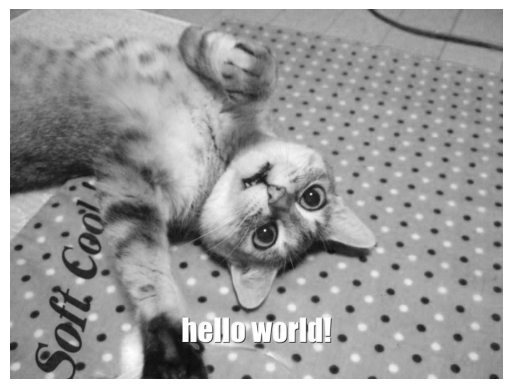

In [10]:
import skimage
import matplotlib.pyplot as plt
balerina = skimage.io.imread('https://cataas.com/cat/says/hello%20world!')
balerina_bw = balerina[:,:,0]
plt.imshow(balerina_bw, cmap='gray')
plt.axis('off')
plt.show()

### Combinare requests + expresii regulate

Scrieti o expresie regulata care extrage toate adresele ipv4 din urmatorul fragment de log, care se gaseste la adresa https://pastebin.com/raw/FCAhtVzF


Puneti aceste adrese intr-o lista unica

In [ ]:
import requests

r = requests.get('https://pastebin.com/raw/ZEFADn6k')
if (r.status_code == 200):
  textlog = r.text
  print(textlog)
  ipmatch = '\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}'
  results = re.findall(ipmatch,  textlog)

  ips = set()
  for match in results:
    ips.add(match)

print(ips)

May  8 23:01:17 isp postfix/qmgr[15768]: DA6F36742E82: removed
May  8 23:01:22 isp postfix/smtpd[24660]: connect from unknown[193.32.162.188]
May  8 23:01:22 isp dovecot: auth: Warning: auth client 0 disconnected with 1 pending requests: Connection reset by peer
May  8 23:01:24 isp postfix/smtpd[28657]: connect from unknown[185.254.37.189]
May  8 23:01:26 isp postfix/smtpd[28657]: warning: unknown[185.254.37.189]: SASL LOGIN authentication failed: UGFzc3dvcmQ6
May  8 23:01:26 isp postfix/smtpd[28657]: lost connection after AUTH from unknown[185.254.37.189]
May  8 23:01:26 isp postfix/smtpd[28657]: disconnect from unknown[185.254.37.189]
May  8 23:01:30 isp postfix/smtpd[24660]: lost connection after AUTH from unknown[193.32.162.188]
May  8 23:01:30 isp postfix/smtpd[24660]: disconnect from unknown[193.32.162.188]
May  8 23:01:33 isp postfix/smtpd[28657]: connect from unknown[185.254.37.189]
May  8 23:01:36 isp postfix/smtpd[7789]: connect from unknown[118.41.204.67]
May  8 23:01:37 isp

In [ ]:
wit = 'UGFzc3dvcmQ6'

import base64

print (base64.b64decode(wit))

b'Password:'


Există multe liste de API-uri disponibile gratuit. Una dintre ele este aici: [https://github.com/public-apis/public-apis](https://github.com/public-apis/public-apis)

API Metar (vremea pe aeroporturi)

In [ ]:
r = requests.get('http://tgftp.nws.noaa.gov/data/observations/metar/stations/LROP.TXT')
if (r.status_code == 200):
    print(r.headers)

{'Date': 'Sat, 13 Apr 2024 17:33:30 GMT', 'Server': 'Apache', 'X-Frame-Options': 'SAMEORIGIN', 'X-Content-Type-Options': 'nosniff', 'X-XSS-Protection': '1; mode=block', 'Last-Modified': 'Sat, 13 Apr 2024 17:04:14 GMT', 'Accept-Ranges': 'bytes', 'Vary': 'Accept-Encoding', 'Content-Encoding': 'gzip', 'Content-Length': '81', 'Keep-Alive': 'timeout=300, max=100', 'Connection': 'Keep-Alive', 'Content-Type': 'text/plain; charset=UTF-8', 'Strict-Transport-Security': 'max-age=31536000; includeSubdomains; preload'}


Content-type este text/plain - ceea ce am primit este un document text (ASCII)

In [ ]:
print (r.content)

### Retete de coctail

In [ ]:
r = requests.get('https://www.thecocktaildb.com/api/json/v1/1/search.php?f=a')

data = r.json()

print(data)

{'drinks': [{'idDrink': '17222', 'strDrink': 'A1', 'strDrinkAlternate': None, 'strTags': None, 'strVideo': None, 'strCategory': 'Cocktail', 'strIBA': None, 'strAlcoholic': 'Alcoholic', 'strGlass': 'Cocktail glass', 'strInstructions': 'Pour all ingredients into a cocktail shaker, mix and serve over ice into a chilled glass.', 'strInstructionsES': 'Vierta todos los ingredientes en una coctelera, mezcle y sirva con hielo en un vaso frío.', 'strInstructionsDE': 'Alle Zutaten in einen Cocktailshaker geben, mischen und über Eis in ein gekühltes Glas servieren.', 'strInstructionsFR': None, 'strInstructionsIT': 'Versare tutti gli ingredienti in uno shaker, mescolare e servire con ghiaccio in un bicchiere freddo.', 'strInstructionsZH-HANS': None, 'strInstructionsZH-HANT': None, 'strDrinkThumb': 'https://www.thecocktaildb.com/images/media/drink/2x8thr1504816928.jpg', 'strIngredient1': 'Gin', 'strIngredient2': 'Grand Marnier', 'strIngredient3': 'Lemon Juice', 'strIngredient4': 'Grenadine', 'strIn

In [ ]:
from IPython.display import Image, display

In [ ]:
for drink in data['drinks']:
  print('---------------')
  print(drink['idDrink'])
  print(drink['strCategory'])
  print(drink['strInstructions'])
  print(drink['strDrinkThumb'])
  display(Image(url=drink['strDrinkThumb'], width=200))

  for key, value in drink.items():
    if key.startswith("strIngredient") and value is not None:
        print(f"{key}: {value}")


---------------
17222
Cocktail
Pour all ingredients into a cocktail shaker, mix and serve over ice into a chilled glass.
https://www.thecocktaildb.com/images/media/drink/2x8thr1504816928.jpg


strIngredient1: Gin
strIngredient2: Grand Marnier
strIngredient3: Lemon Juice
strIngredient4: Grenadine
---------------
13501
Shot
Layered in a shot glass.
https://www.thecocktaildb.com/images/media/drink/tqpvqp1472668328.jpg


strIngredient1: Amaretto
strIngredient2: Baileys irish cream
strIngredient3: Cognac
---------------
17225
Cocktail
Shake all the ingredients in a cocktail shaker and ice then strain in a cold glass.
https://www.thecocktaildb.com/images/media/drink/l3cd7f1504818306.jpg


strIngredient1: Gin
strIngredient2: Grenadine
strIngredient3: Heavy cream
strIngredient4: Milk
strIngredient5: Egg White
---------------
14610
Shot
Poor in the 151 first followed by the 101 served with a Coke or Dr Pepper chaser.
https://www.thecocktaildb.com/images/media/drink/xuxpxt1479209317.jpg


strIngredient1: 151 proof rum
strIngredient2: Wild Turkey
---------------
17837
Ordinary Drink
In a shaker half-filled with ice cubes, combine all of the ingredients. Shake well. Strain into a cocktail glass.
https://www.thecocktaildb.com/images/media/drink/v0at4i1582478473.jpg


...

strIngredient1: Kahlua
strIngredient2: Baileys irish cream
strIngredient3: Frangelico
strIngredient4: Coffee
strIngredient5: Cream
---------------
11014
Ordinary Drink
Shake all ingredients with ice and strain contents into a cocktail glass. Sprinkle nutmeg on top and serve.
https://www.thecocktaildb.com/images/media/drink/0clus51606772388.jpg


strIngredient1: Gin
strIngredient2: Creme de Cacao
strIngredient3: Light cream
strIngredient4: Nutmeg
---------------
12756
Ordinary Drink
Mix and fill up with soda water. Drunk by finns on a sunny day any time of the year and day.
https://www.thecocktaildb.com/images/media/drink/7dkf0i1487602928.jpg


strIngredient1: Vodka
strIngredient2: Lime juice
strIngredient3: Soda water
---------------
11021
Ordinary Drink
Shake all ingredients (except lemon peel) with ice and strain into a cocktail glass. Top with the twist of lemon peel and serve.
https://www.thecocktaildb.com/images/media/drink/uwvyts1483387934.jpg


strIngredient1: Dry Vermouth
strIngredient2: Bourbon
strIngredient3: Blackberry brandy
strIngredient4: Lemon juice
strIngredient5: Lemon peel
---------------
15941
Ordinary Drink
Pour the Campari and vermouth over ice into glass, add a splash of soda water and garnish with half orange slice.
https://www.thecocktaildb.com/images/media/drink/709s6m1613655124.jpg


strIngredient1: Campari
strIngredient2: Sweet Vermouth
strIngredient3: Lemon peel
strIngredient4: Orange peel


Creem o lista cu toate ingredientele disponibile

In [ ]:
ingrediente = []
for drink in data['drinks']:
  for key, value in drink.items():
    if key.startswith("strIngredient") and value is not None:
        ingrediente.append(value)

print(ingrediente)
print(len(ingrediente))
unique_ingredients = set(ingrediente)
print(len(unique_ingredients))

['Gin', 'Grand Marnier', 'Lemon Juice', 'Grenadine', 'Amaretto', 'Baileys irish cream', 'Cognac', 'Gin', 'Grenadine', 'Heavy cream', 'Milk', 'Egg White', '151 proof rum', 'Wild Turkey', 'Dark rum', 'Lemon juice', 'Grenadine', 'Absolut Vodka', 'Gin', 'Tonic water', 'Applejack', 'Grapefruit juice', 'Vodka', 'Pisang Ambon', 'Apple juice', 'Lemon juice', 'Lemonade', 'Orange juice', 'Grapefruit juice', 'Apple juice', 'Maraschino cherry', 'Strawberry schnapps', 'Orange juice', 'Cranberry juice', 'Club soda', 'Dark rum', 'Peach nectar', 'Orange juice', 'Dark rum', 'Kahlua', 'Egg white', 'Gin', 'Vermouth', 'Applejack', 'Triple sec', 'Lemon juice', 'Light rum', 'Triple sec', 'Lime juice', 'Sugar', 'Egg white', 'Mint', 'Scotch', 'Sweet Vermouth', 'Dry Vermouth', 'Orange bitters', 'Gin', 'lemon juice', 'maraschino liqueur', 'Vodka', 'Creme de Banane', 'Orange juice', 'Jack Daniels', 'Midori melon liqueur', 'Sour mix', 'Grenadine', 'Orange juice', 'Pineapple juice', 'Kahlua', 'Baileys irish cream'

Orase preluate de la API-ul geocities

In [ ]:
accumulated_cities = []
url = "http://geodb-free-service.wirefreethought.com/v1/geo/places"
for offset in range(0, 100, 10):
    params = {"offset": offset, "limit": 10}
    response = requests.get(url, params=params)
    data = response.json()
    cities = [place for place in data["data"]]
    accumulated_cities.extend(cities)


In [ ]:
for city in accumulated_cities[1:3]:
    print(city['population'])

490035
766936


In [ ]:
city_with_max_population = max(accumulated_cities, key=lambda x: x["population"])

city_with_min_population = min(accumulated_cities, key=lambda x: x["population"])

total_population = sum([city["population"] for city in accumulated_cities])

countries = set(city["country"] for city in accumulated_cities)

print("City with maximum population:")
print(city_with_max_population)

print("\nCity with minimum population:")
print(city_with_min_population)

print("\nTotal population:")
print(total_population)

print("\nTotal population:")
print(countries)


City with maximum population:
{'id': 216, 'wikiDataId': 'Q5838', 'type': 'CITY', 'name': 'Kabul', 'country': 'Afghanistan', 'countryCode': 'AF', 'region': 'Kabul', 'regionCode': 'KAB', 'regionWdId': 'Q188933', 'latitude': 34.532777777, 'longitude': 69.165833333, 'population': 4273156, 'distance': None, 'placeType': 'CITY'}

City with minimum population:
{'id': 12, 'wikiDataId': 'Q193226', 'type': 'CITY', 'name': 'Saranda', 'country': 'Albania', 'countryCode': 'AL', 'region': 'Vlorë County', 'regionCode': '12', 'regionWdId': 'Q192849', 'latitude': 39.883333333, 'longitude': 20.016666666, 'population': 41000, 'distance': None, 'placeType': 'CITY'}

Total population:
27474489

Total population:
{'Angola', 'Antigua and Barbuda', 'Armenia', 'Afghanistan', 'Albania', 'United Arab Emirates'}


### Afisarea pe harta

In [ ]:
!pip install cartopy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 32.1 MB/s eta 0:00:00


In [ ]:
print(len(accumulated_cities))

100


/usr/local/lib/python3.10/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


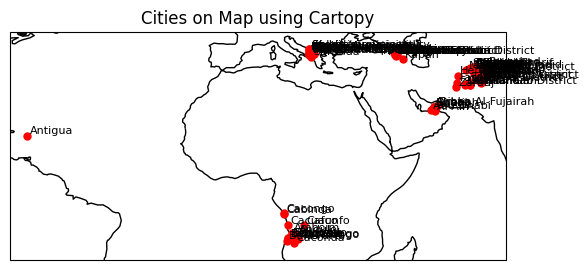

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

lons = [city["longitude"] for city in accumulated_cities]
lats = [city["latitude"] for city in accumulated_cities]

# Calculate the extent of the map
min_lon, max_lon = min(lons), max(lons)
min_lat, max_lat = min(lats), max(lats)

# Create a map with a PlateCarree projection
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines()

# Set the extent of the map
ax.set_extent([min_lon - 5, max_lon + 5, min_lat - 5, max_lat + 5], crs=ccrs.PlateCarree())


# Plot the cities on the map
for city in accumulated_cities:
    lon, lat = city["longitude"], city["latitude"]
    ax.plot(lon, lat, 'ro', markersize=5, transform=ccrs.PlateCarree())
    ax.text(lon + 0.6, lat + 0.6, city["name"], fontsize=8, transform=ccrs.PlateCarree())

# Show the plot
plt.title('Cities on Map using Cartopy')
plt.show()

## Prelucrarea textului preluat din pagini WEB normale

Exemplu de izolare a textului dintr-o pagina web folosind justext

Justext este unul dintre proiectele care incearca izolarea textului util dintr-o pagina web. Procesul este cunoscut sub numele de "boilerplate removal".

[justext](https://pypi.org/project/jusText/)

In [ ]:
import sys
!{sys.executable} -m pip install justext

import justext


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.8/837.8 kB 9.3 MB/s eta 0:00:00


In [ ]:
surl = 'https://www.techrepublic.com/article/what-is-hierarchical-storage-management/'

response = requests.get(surl)


print(response.text)

In [ ]:
paragraphs = justext.justext(response.content, justext.get_stoplist("English"))
jstext = ''
for paragraph in paragraphs:
  if not paragraph.is_boilerplate:
    jstext = jstext + paragraph.text

print (jstext)

An overview of hierarchical storage managementHSM allows you to store data in a secure, cost-efficient manner. Here's what you need to know about it.Image: sdecoret/Adobe StockIf you’re responsible for managing enterprise data, you know that storage can be both a blessing and a curse. On the one hand, having access to large amounts of data can be immensely helpful in making business decisions. On the other hand, storing all that data can be expensive and downright chaotic to manage.That’s where hierarchical storage management comes in. HSM is a system for storing data in a secure, cost-efficient manner. In this guide, we give you a short crash course on HSM, what it is, how it works and some of the benefits it can offer your organization.What is HSM?HSM, or hierarchical storage management, is a system for storing data in a secure, cost-efficient manner. The basic idea behind HSM is to store data on the most appropriate type of storage media, depending on how frequently the data is acce

Exemplu de izolare a textului dintr-o pagina web folosind trafilatura

Trafilatura este un pachet Python (insotit de un utilitar la linia de comanda) care poate fi utilizat pentru acumularea textului de pe internet.

[trafilatura](https://trafilatura.readthedocs.io/en/latest/index.html)

In primul rand, pentru cei care nu au instalat modulul trebuie rulata comanda pip corespunzatoare

In [ ]:
!{sys.executable} -m pip install trafilatura

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.8/263.8 kB 11.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 12.9 MB/s eta 0:00:00


In [ ]:
from trafilatura import fetch_url, extract

surl = 'https://www.techrepublic.com/article/what-is-hierarchical-storage-management/'

downloaded = fetch_url(surl)

downloaded is None  # assuming the download was successful
False

result = extract(downloaded)

print(result)

If you’re responsible for managing enterprise data, you know that storage can be both a blessing and a curse. On the one hand, having access to large amounts of data can be immensely helpful in making business decisions. On the other hand, storing all that data can be expensive and downright chaotic to manage.
SEE: Cloud data storage policy (TechRepublic Premium)
That’s where hierarchical storage management comes in. HSM is a system for storing data in a secure, cost-efficient manner. In this guide, we give you a short crash course on HSM, what it is, how it works and some of the benefits it can offer your organization.
Jump to:
What is HSM?
HSM, or hierarchical storage management, is a system for storing data in a secure, cost-efficient manner. The basic idea behind HSM is to store data on the most appropriate type of storage media, depending on how frequently the data is accessed.
For example, data that is accessed frequently can be stored on more expensive, higher-performance storag

### Analiza textului

variabila result contine un text cat de cat coerent in limba engleza.

Textele pot fi analizate folosind tehnici tip NLP (Natural Language Processing)

Una dintre tehnicile care fac parte din NLP este Named Entity Recognition (recunoasterea si extragerea numelor proprii). Eista mai multe proiecte care se ocupa de NER:

[spacy](https://spacy.io/), [exemplu spacy](https://www.analyticsvidhya.com/blog/2021/06/nlp-application-named-entity-recognition-ner-in-python-with-spacy/)

[nltk](https://www.nltk.org/)

In [ ]:
!{sys.executable} -m pip install spacy

Spacy are nevoie de descarcarea unor modele lingvistice

In [ ]:
import sys
!{sys.executable} -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 22.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
from spacy import displacy

NER = spacy.load("en_core_web_sm")

text1= NER(result)

for ent in text1.ents:
    print(ent.text, ent.start_char, ent.end_char, ent.label_)

TechRepublic Premium 344 364 ORG
HSM 421 424 ORG
HSM 541 544 ORG
Jump 628 632 PERSON
HSM 645 648 ORG
HSM 650 653 ORG
HSM 778 781 ORG
TechRepublic Premium 1206 1226 ORG
HSM 1228 1231 ORG
today 1526 1531 DATE
HSM 1600 1603 ORG
HSM 1618 1621 ORG
HSM 2047 2050 ORG
CPU 2110 2113 ORG
SRAM 2170 2174 ORG
DRAM 2246 2250 ORG
HSM 2285 2288 ORG
HSM 2315 2318 ORG
three 2348 2353 CARDINAL
HSM 2643 2646 ORG
TechRepublic 2817 2829 ORG
Size-Temperature Replacement 2989 3017 ORG
The Heuristic Threshold 3135 3158 ORG
HSM 3295 3298 ORG
HSM 3355 3358 ORG
HSM 3814 3817 ORG
HSM 3832 3835 ORG
HSM 4007 4010 ORG
HSM 4429 4432 ORG
HSM 4678 4681 ORG
HSM 4717 4720 ORG
today 4755 4760 DATE
HSM 4778 4781 ORG
IBM 4814 4817 ORG
NetApp 4853 4859 ORG
HPE 3PAR StoreServe 4870 4889 PRODUCT
Huawei 4892 4898 ORG
Qumulo Core 4918 4929 PERSON
TechRepublic 4994 5006 ORG
HSM 5092 5095 ORG
today 5134 5139 DATE


Articolele tehnice nu sunt teribil de utile in NLP. Sa incercam sa gasim o stire normala

https://www.bbc.com/future/article/20240412-the-secret-scandinavian-a-bomb-project

In [ ]:
from trafilatura import fetch_url, extract

surl = 'https://edition.cnn.com/2024/04/13/tech/ai-jobs-threat-guaranteed-income/index.html'

downloaded = fetch_url(surl)

bbcpage = extract(downloaded)

print(bbcpage)

Michael Tubbs was born and raised in Stockton, California, roughly a one-hour drive from Silicon Valley, the birthplace of the AI revolution that’s now forecast to forever change the way Americans live and work.
But despite coming of age in Big Tech’s backyard, the America that Tubbs grew up in was marked by “scarcity and poverty,” he told CNN. Tubbs, 33, was born to a teenage mother, whom he says he never saw when he was younger because “she was always working — and it was never enough.”
His own experiences led him to think about different ways that the wealthiest country in the world could help ameliorate poverty. When Tubbs went on to become the first Black mayor of his hometown in 2016, he spearheaded a guaranteed income pilot program in 2019 that did something simple yet radical: Give out free money with no strings attached.
That idea of guaranteed income is receiving renewed interest as AI becomes an increasing threat to Americans’ livelihoods.
Global policymakers and business le

### Named Entity Regognition

Parte din NLP, identificarea tipurilor de numelor proprii presupune analiza textului si "ghicirea" tipului de entitate numită. Rezultatul este o listă de nume însoțită de tipul acestora (loc, persoana, etc. )

Spacy recunoaște următoarele entități

| Entitate | Descriere          |
|----------|--------------------|
|PERSON:   |   People, including fictional.                    |
|NORP sau NAT_REL_POL:     |   Nationalities or religious or political groups. |
|FAC:      |   Buildings, airports, highways, bridges, etc.    |
|ORG:      |   Companies, agencies, institutions, etc.         |
|GPE:      |   Countries, cities, states.                      |
|LOC:      |   Non-GPE locations, mountain ranges, bodies of water. |
|PRODUCT:  |   Objects, vehicles, foods, etc. (Not services.) |
|EVENT:    |   Named hurricanes, battles, wars, sports events, etc. |
|WORK_OF_ART:| Titles of books, songs, etc. |
|LAW:       |  Named documents made into laws. |
|LANGUAGE:  |  Any named language. |
|DATE:      |  Absolute or relative dates or periods. |
|TIME:      |  Times smaller than a day. |
|PERCENT:   |  Percentage, including ”%“. |
|MONEY:     |  Monetary values, including unit. |
|QUANTITY:  |  Measurements, as of weight or distance. |
|ORDINAL:   |  “first”, “second”, etc. |
|CARDINAL:  |  Numerals that do not fall under another type. |

In [ ]:
import spacy
from spacy import displacy

NER = spacy.load("en_core_web_sm")

text1= NER(bbcpage)

for ent in text1.ents:
    # if ent.label_ == 'PERSON':
        print(ent.text, ent.start_char, ent.end_char, ent.label_)

NameError: name 'bbcpage' is not defined

Incercam un articol in limba romana

https://www.hotnews.ro/stiri-alegeri2024-27052128-exclusiv-bresa-securitate-autoritatea-electorala-permanenta-datele-personale-ale-expertilor-electorali-fost-dezvaluite-din-eroare.htm



In [ ]:
hnurl = "https://www.hotnews.ro/stiri-alegeri2024-27052128-exclusiv-bresa-securitate-autoritatea-electorala-permanenta-datele-personale-ale-expertilor-electorali-fost-dezvaluite-din-eroare.htm"

downloaded = fetch_url(hnurl)

hnpage = extract(downloaded)

print(hnpage)

Incidentul s-a produs joi, 11 aprilie, iar pentru câteva ore mai multe date personale, de exemplu codul numeric personal, ale experților electorali au putut să fie accesate pe un mail nesecurizat, a declarat, pentru HotNews.ro, președintele AEP, Toni Greblă.
Experții electorali sunt persoanele care pot deveni președinți ai birourilor electorale ale secțiilor de votare din țară sau locțiitorii lor.
Scurgerea de informații a fost raportată, vineri, Autorității Naționale de Supraveghere a Datelor cu caracter personal, a confirmat Toni Greblă pentru HotNews.ro.
Termenul legal pentru semnalarea scurgerilor de date este de 72 de ore. Potrivit informațiilor, codul numeric personal pentru 1.300 de persoane din corpul experților electorali a fost dezvăluit.
„Miercuri seara, până joi dimineața la ora 2, personalul AEP a fost angrenat în operațiunea de numărare și verificare a semnăturilor de la candidații pentru europarlamentare. Ultimul candidat a depus documentația la ora 23.00, miercuri noapt

Alte modele spacy pot fi gasite la adresa:

https://spacy.io/models

Exista un model pentru limba romana, sa il testam

In [ ]:
import sys
!{sys.executable} -m spacy download ro_core_news_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.5/568.5 MB 2.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ro_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
from spacy import displacy

NER = spacy.load("ro_core_news_lg")

text1= NER(hnpage)

for ent in text1.ents:
    print(ent.text, ent.start_char, ent.end_char, ent.label_)

joi, 11 aprilie 22 37 DATETIME
câteva ore 50 60 DATETIME
experților 126 136 PERSON
președintele 228 240 PERSON
AEP 241 244 ORGANIZATION
Toni Greblă 246 257 PERSON
Experții 259 267 PERSON
persoanele 284 294 PERSON
președinți 311 321 PERSON
locțiitorii 384 395 PERSON
vineri 443 449 DATETIME
Autorității Naționale de Supraveghere a Datelor cu caracter personal 451 519 ORGANIZATION
Toni Greblă 533 544 PERSON
72 de ore 625 634 DATETIME
1.300 690 695 NUMERIC_VALUE
persoane 699 707 PERSON
Miercuri seara, până joi dimineața la ora 2 760 803 DATETIME
personalul 805 815 PERSON
AEP 816 819 ORGANIZATION
candidații 898 908 PERSON
candidat 942 950 PERSON
ora 23.00 975 984 DATETIME
miercuri noaptea 986 1002 DATETIME
Joi dimineața 1004 1017 DATETIME
experților 1169 1179 PERSON
Toni Greblă 1262 1273 PERSON
Președintele 1293 1305 PERSON
AEP 1306 1309 ORGANIZATION
Greblă 1419 1425 PERSON
personalului 1455 1467 PERSON
AEP 1468 1471 ORGANIZATION
o oră 1507 1512 DATETIME
30 1583 1585 NUMERIC_VALUE
35 1588 15

### POS tagging

Part of Speech tagging implică marcarea tuturor elementelor de text cu informații despre valoarea morfologica. Aceste informații sunt atribute ale obiectului de tip "spacy.tokens.token.Token". Cateva atribute interesante (lista copleta [aici](https://spacy.io/api/token#attributes) )

| Atribut     | Tip  | Descriere |
|------       |----- |-------------|
|text         | str  | continutul real textual al tokenului |
|text_with_ws | str  | continutul textual cu spatiul ulterior, daca este prezent |
| ent_type_   | str  | Tipul named entity (daca este cazul)   |
| lemma       | str  | Rădăcina cuvantului respectiv          |
| is_alpha    | bool | Tokenul este format din  caractere alfanumerice? |
| is_ascii    | bool | Tokenul este format din caractere ASCII         |
| is_digit    | bool | Tokenul este format din cifre            |
| pos_        | str  | Denumirea pos [din lista universala](https://universaldependencies.org/u/pos/) |
| dep_        | str  | Relatia de dependenta sintactica |

In [ ]:
for token in text1:
    print('Text: ' + token.text + ' Lema: ' + token.lemma_ + ' POS: ' + token.pos_ + ' Tag: ' + token.tag_  + ' DEP: ' + token.dep_)


Text: Incidentul Lema: Incidentul POS: NOUN Tag: Ncmsry DEP: nsubj
Text: s- Lema: sine POS: PRON Tag: Px3--a--y-----w DEP: expl:pv
Text: a Lema: avea POS: AUX Tag: Va--3s DEP: aux
Text: produs Lema: produce POS: VERB Tag: Vmp--sm DEP: ROOT
Text: joi Lema: joi POS: NOUN Tag: Ncf--n DEP: obl
Text: , Lema: , POS: NOUN Tag: Ncf--n DEP: punct
Text: 11 Lema: 11 POS:  Tag: Mc-s-d DEP: nummod
Text: aprilie Lema: aprilie POS: NOUN Tag: Ncm--n DEP: nmod:tmod
Text: , Lema: , POS: PUNCT Tag: COMMA DEP: punct
Text: iar Lema: iar POS: ADV Tag: Rc DEP: cc
Text: pentru Lema: pentru POS: ADP Tag: Spsa DEP: case
Text: câteva Lema: câtva POS: DET Tag: Di3fpr DEP: det
Text: ore Lema: oră POS: NOUN Tag: Ncfp-n DEP: nmod
Text: mai Lema: mai POS: ADV Tag: Rp DEP: advmod
Text: multe Lema: mult POS: DET Tag: Di3fp DEP: det
Text: date Lema: dată POS: NOUN Tag: Ncfp-n DEP: nsubj
Text: personale Lema: personal POS: ADJ Tag: Afpfp-n DEP: amod
Text: , Lema: , POS: PUNCT Tag: COMMA DEP: punct
Text: de Lema: de POS: 

## Segmentarea imaginilor

Segmentarea imaginilor este o operatie destul de frecventa in analiza automata a imaginilor repetitive cu contrast similar. In masura in care avem o serie de imagini similare in care trebuie sa numaram automat obiectele, putem aplica un astfel de algoritm. Nu se urmareste precizia totala, incercam sa fim cat mai aproape de numarul real.

In [12]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Our image processing tools
import skimage.filters
import skimage.io
import skimage.morphology
import skimage.color
from skimage import data

Biblioteca skimage este insotita de o serie de imagini de test, una dintre ele fiind extrem de potrivita cu aceasta serie de algoritmi.

In [13]:
coins = data.coins()

print(type(coins))
print(coins.shape)

<class 'numpy.ndarray'>
(303, 384)


[[119 121 122 ...  68  70  75]
 [119 124 126 ...  64  65  69]
 [122 126 132 ...  63  62  63]
 ...
 [123 122 121 ...  63  62  61]
 [122 122 121 ...  61  61  61]
 [120 120 120 ...  60  61  63]]


imaginile nu sunt stocate in format grafic ci in format numpy - ca matrice de trei strate.

In [ ]:
print(coins[25:35])

[[119 121 122 ...  68  70  75]
 [119 124 126 ...  64  65  69]
 [122 126 132 ...  63  62  63]
 ...
 [123 122 121 ...  63  62  61]
 [122 122 121 ...  61  61  61]
 [120 120 120 ...  60  61  63]]


Putem folosi imshow pentru a vedea imaginea

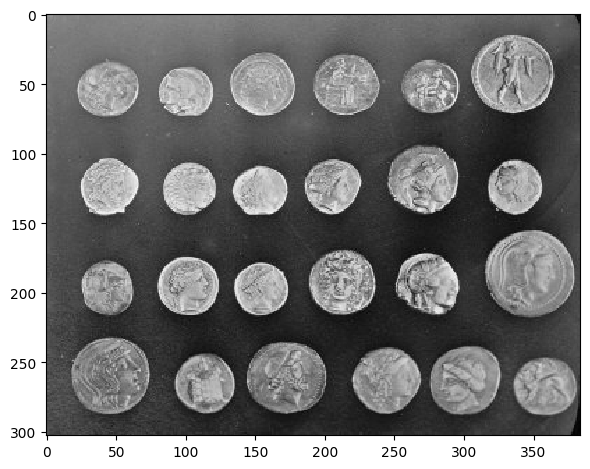

In [ ]:
skimage.io.imshow(coins)
skimage.io.show()

Putem afisa histograma imaginii (numarul de pixeli a fiecari intensitati de gri)

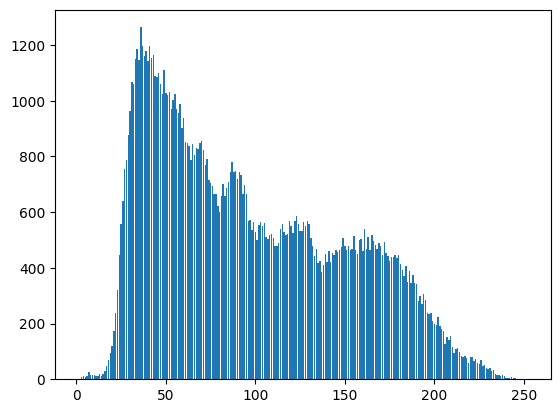

In [ ]:
from skimage.exposure import histogram
hist, hist_centers = histogram(coins)
plt.bar(hist_centers, hist)
plt.show()

### segmentare bazata pe valoare de prag (threshold)

Porneste de la ideea ca exista o valoare de prag, astfel incat toti pixelii care se gasesc deasupra acelei valori sunt parte din obiecte iar toti cei care se gasesc dedesubt sunt parte din fundal.

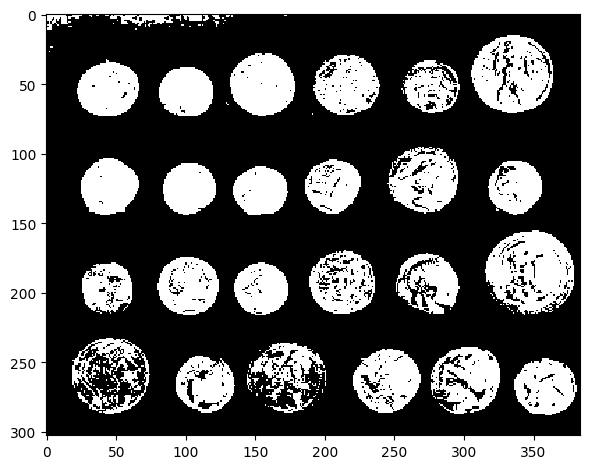

In [ ]:
img120 = coins > 130

skimage.io.imshow(img120)
skimage.io.show()


Segmentarea este imperfecta, obiectele au ramas cu multe goluri. Exista algoritmi care permit umplerea golurilor, skimage ofera astfel de algoritmi.

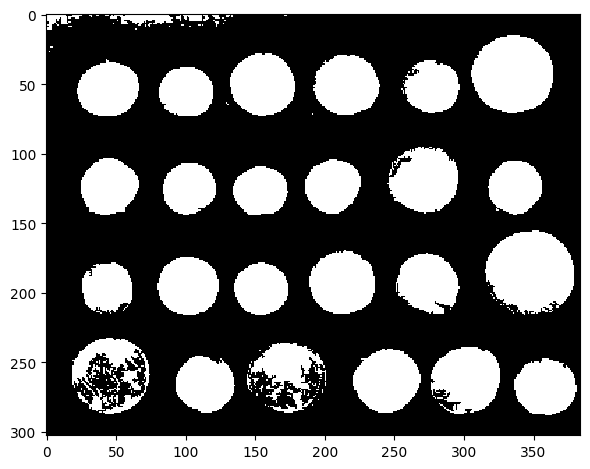

In [ ]:
from scipy import ndimage as ndi
fill_img120 = ndi.binary_fill_holes(img120)
skimage.io.imshow(fill_img120)
skimage.io.show()

ndi_label scaneaza imaginea si identifica ca obiecte separate toate regiunile cu pixeli conectati.

In [ ]:
label_objects, nb_labels = ndi.label(fill_img120)
sizes = np.bincount(label_objects.ravel())
mask_sizes = sizes > 20
mask_sizes[0] = 0
coins_cleaned = mask_sizes[label_objects]


In [ ]:
from skimage import data, filters, measure

labels = measure.label(coins_cleaned)
num_objects = labels.max()
print(num_objects)

36


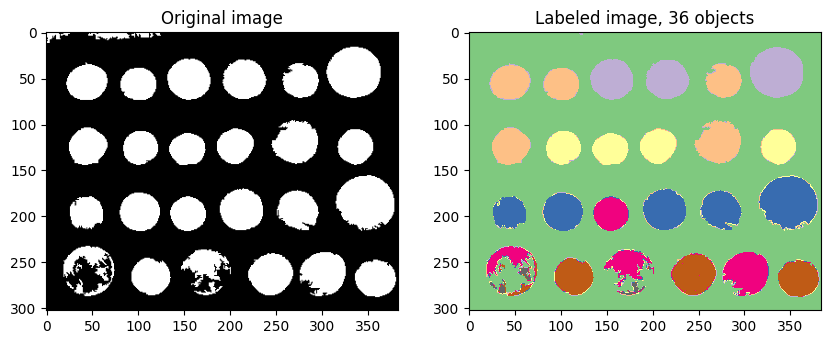

In [ ]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
ax[0].imshow(coins_cleaned, cmap='gray')
ax[0].set_title('Original image')
ax[1].imshow(labels, cmap='Accent')
ax[1].set_title('Labeled image, %d objects' % num_objects)
plt.show()

### Segmentare bazata pe detectia muchiilor

Incepem din nou de la imaginea grayscale

/tmp/ipykernel_46346/863050958.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.imshow(coins)
/tmp/ipykernel_46346/863050958.py:2: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.show()


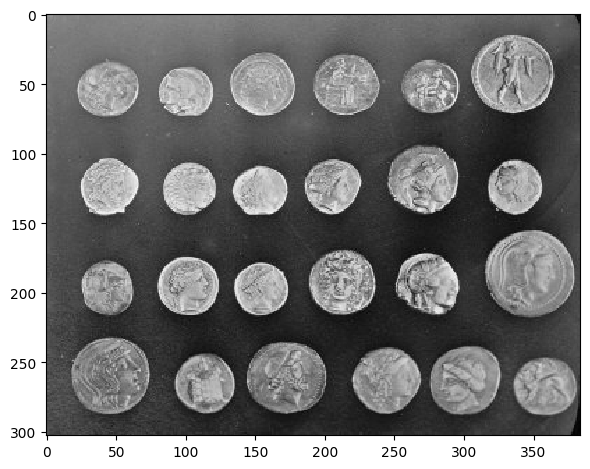

In [14]:
skimage.io.imshow(coins)
skimage.io.show()

/tmp/ipykernel_46346/51233653.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.imshow(edges)
/tmp/ipykernel_46346/51233653.py:4: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.show()


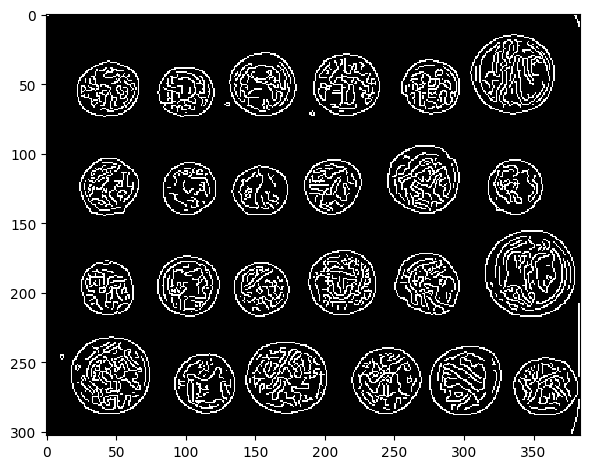

In [15]:
from skimage.feature import canny
edges = canny(coins/255.)
skimage.io.imshow(edges)
skimage.io.show()

/tmp/ipykernel_46346/3708109902.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.imshow(fill_holes)
/tmp/ipykernel_46346/3708109902.py:4: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.show()


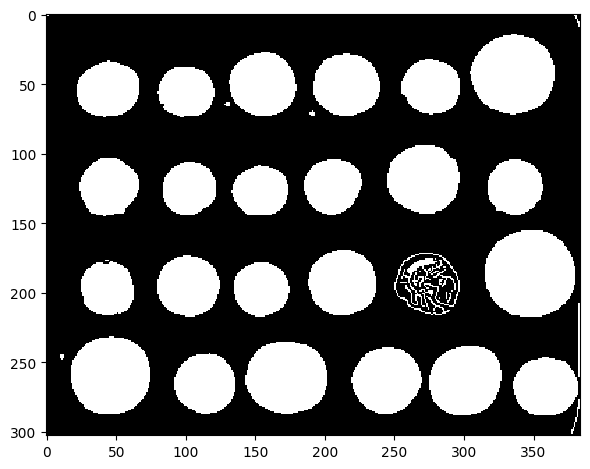

In [16]:
from scipy import ndimage as ndi
fill_holes = ndi.binary_fill_holes(edges)
skimage.io.imshow(fill_holes)
skimage.io.show()

In [17]:
label_objects, nb_labels = ndi.label(fill_holes)
sizes = np.bincount(label_objects.ravel())
mask_sizes = sizes > 20
mask_sizes[0] = 0
coins_cleaned = mask_sizes[label_objects]

In [18]:
from skimage import data, filters, measure

labels = measure.label(coins_cleaned)
num_objects = labels.max()
print(num_objects)

26


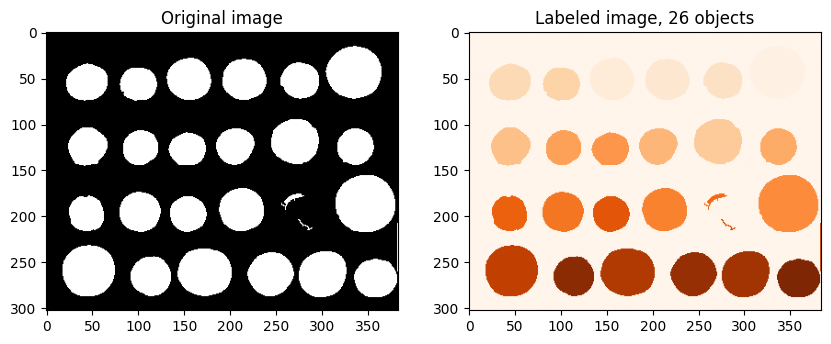

In [24]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
ax[0].imshow(coins_cleaned, cmap='gray')
ax[0].set_title('Original image')
ax[1].imshow(labels, cmap='Oranges')
ax[1].set_title('Labeled image, %d objects' % num_objects)
plt.show()

Watershed transform

/tmp/ipykernel_46346/1119845918.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.imshow(elevation_map)
/tmp/ipykernel_46346/1119845918.py:4: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.show()


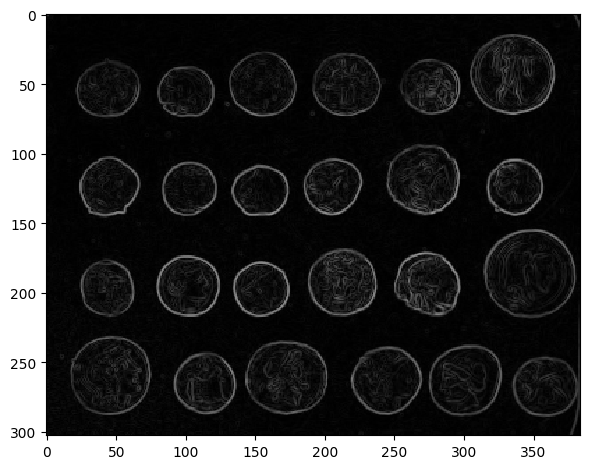

In [34]:
from skimage.filters import sobel
elevation_map = sobel(coins)
skimage.io.imshow(elevation_map)
skimage.io.show()

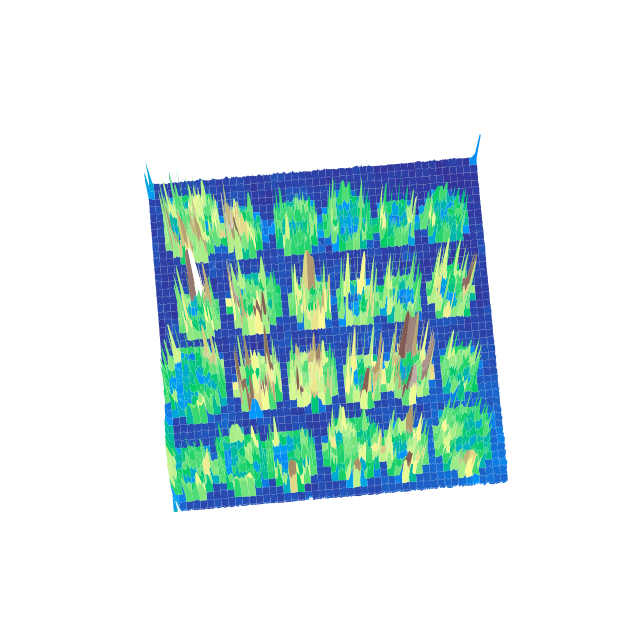

In [35]:
from mpl_toolkits.mplot3d import Axes3D

x = np.arange(elevation_map.shape[1])
y = np.arange(elevation_map.shape[0])
X, Y = np.meshgrid(x, y)
Z = elevation_map


fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='terrain')
ax.view_init(elev=80, azim=85)
ax.set_proj_type('persp')
ax.set_axis_off()
plt.show()

In [36]:
markers = np.zeros_like(coins)
markers[coins < 20] = 1
markers[coins > 150] = 2

In [37]:
from skimage.segmentation import watershed
segmentation = watershed(elevation_map, markers)

/tmp/ipykernel_46346/2516555142.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.imshow(segmentation)
/usr/local/lib/python3.12/dist-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)
/tmp/ipykernel_46346/2516555142.py:2: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.show()


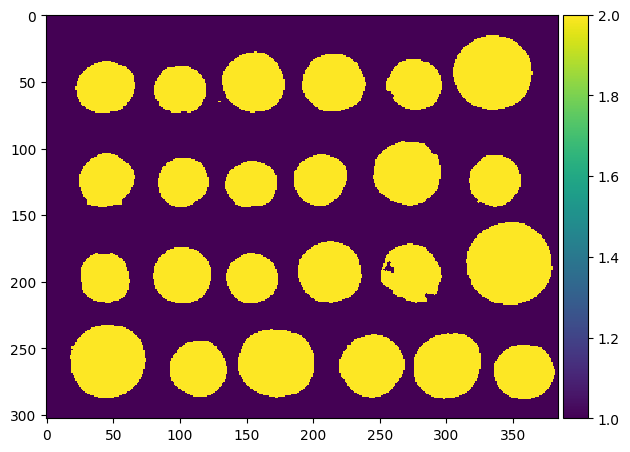

In [38]:
skimage.io.imshow(segmentation)
skimage.io.show()

/tmp/ipykernel_46346/2278032570.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.imshow(segmentation_filled)
/tmp/ipykernel_46346/2278032570.py:3: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.show()


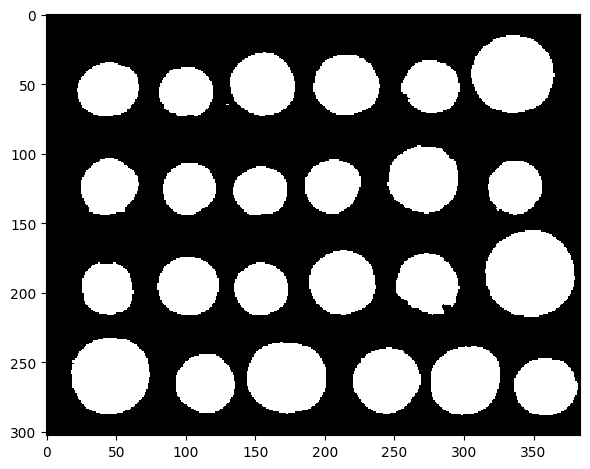

In [39]:
segmentation_filled = ndi.binary_fill_holes(segmentation-1)
skimage.io.imshow(segmentation_filled)
skimage.io.show()

In [40]:
labels = measure.label(segmentation_filled)
num_objects = labels.max()
print(num_objects)

25


/tmp/ipykernel_46346/1369540909.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.imshow(labels)
/usr/local/lib/python3.12/dist-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)
/tmp/ipykernel_46346/1369540909.py:2: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.show()


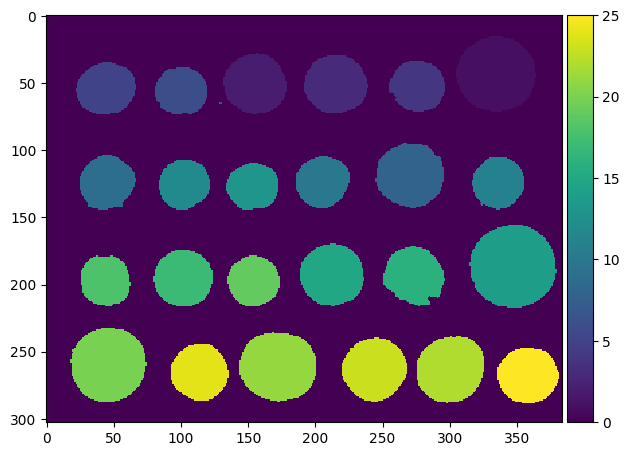

In [41]:
skimage.io.imshow(labels)
skimage.io.show()

## Operatii morfologice

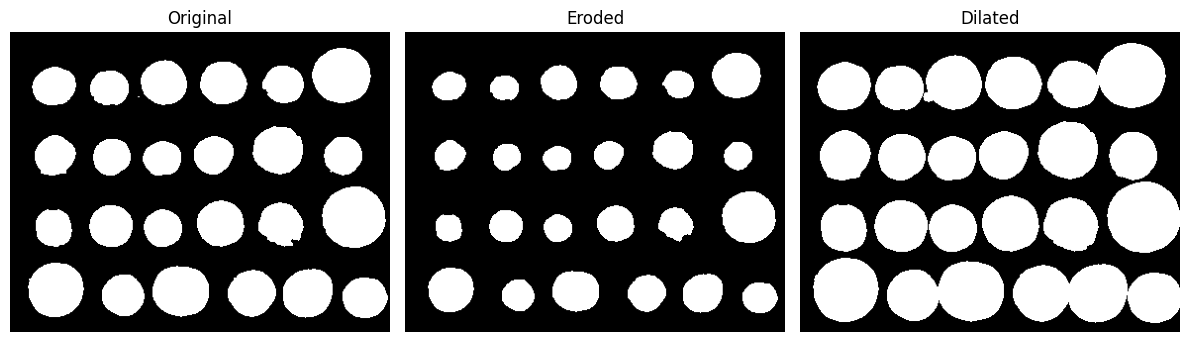

In [ ]:
from skimage import morphology

selem = morphology.disk(5)
eroded = morphology.binary_erosion(segmentation_filled, selem)
dilated = morphology.binary_dilation(segmentation_filled, selem)


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 6))
ax = axes.ravel()
ax[0].imshow(segmentation_filled, cmap='gray')
ax[0].set_title('Original')
ax[1].imshow(eroded, cmap='gray')
ax[1].set_title('Eroded')
ax[2].imshow(dilated, cmap='gray')
ax[2].set_title('Dilated')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

Closing = dilation + erosion

Opening = erosion + dilation

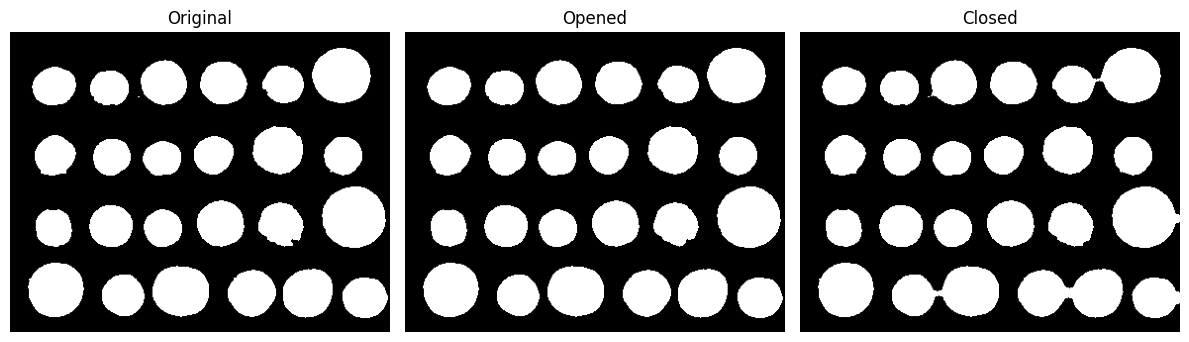

In [ ]:
opened = morphology.binary_opening(segmentation_filled, selem)
closed = morphology.binary_closing(segmentation_filled, selem)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 6))
ax = axes.ravel()
ax[0].imshow(segmentation_filled, cmap='gray')
ax[0].set_title('Original')
ax[1].imshow(opened, cmap='gray')
ax[1].set_title('Opened')
ax[2].imshow(closed, cmap='gray')
ax[2].set_title('Closed')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
labels_opened = measure.label(opened)
num_objects = labels.max()
print(num_objects)

25


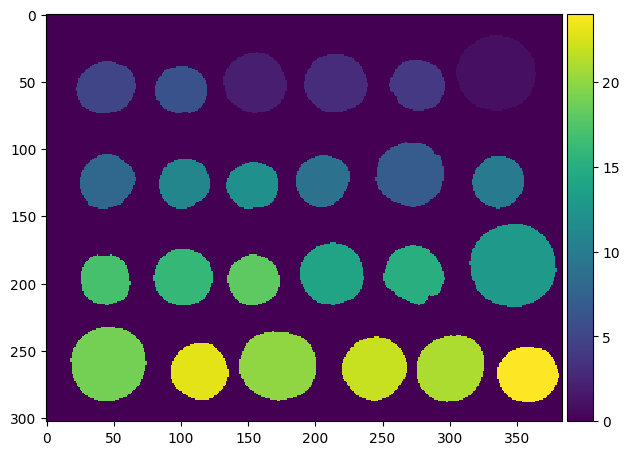

In [ ]:
skimage.io.imshow(labels_opened)
skimage.io.show()